# Differentialgleichungen I: Richtungsfelder und Variablentrennung

Begleitendes Notebook zu *Angew.Mathe.1Differentialgleichungen_S1-13*: Richtungsfelder, Anfangswertprobleme, Variablentrennung und homogene DGL vom Typ $y'=f(y/x)$.

**Voraussetzungen:** `numpy`, `sympy`, `matplotlib`  
**Arbeitsweise:** Zellen der Reihe nach ausführen und die Kontrollausgaben prüfen.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/karkessler/dhbw-mathe3/blob/main/notebooks/differentialgleichungen/01_dgl_variablentrennung_richtungsfelder.ipynb)

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt
sp.init_printing()
plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True

## 1. Newtonsches Abkühlungsgesetz

Das Modell $T'=-k(T-T_U)$ besitzt die Lösung $T(t)=T_U+(T_0-T_U)e^{-kt}$.

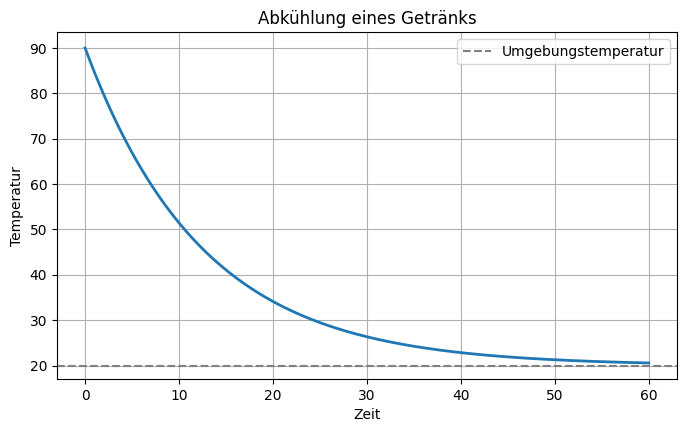

T(30) = 26.35 °C


In [2]:
T_U, T_0, k = 20.0, 90.0, 0.08
t = np.linspace(0, 60, 400)
T = T_U + (T_0 - T_U) * np.exp(-k * t)
plt.plot(t, T, linewidth=2)
plt.axhline(T_U, color='gray', linestyle='--', label='Umgebungstemperatur')
plt.xlabel('Zeit'); plt.ylabel('Temperatur'); plt.legend();
plt.title('Abkühlung eines Getränks'); plt.show()
print(f'T(30) = {T_U + (T_0-T_U)*np.exp(-k*30):.2f} °C')

## 2. Richtungsfeld

Jeder Punkt $(t,T)$ erhält die lokale Steigung $-k(T-T_U)$.

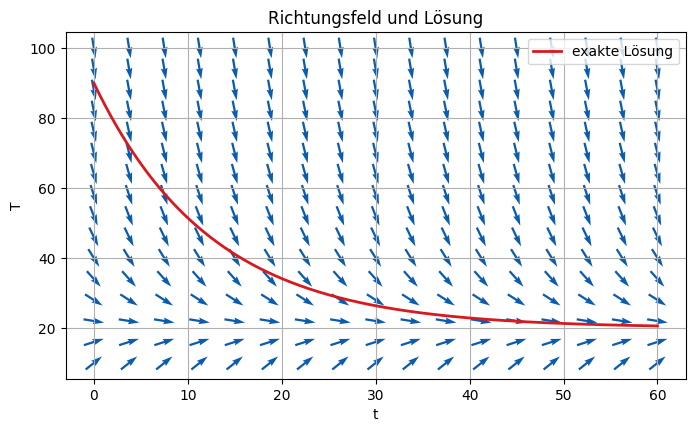

In [3]:
tt = np.linspace(0, 60, 17)
yy = np.linspace(10, 100, 16)
TT, YY = np.meshgrid(tt, yy)
U = np.ones_like(TT)
V = -k * (YY - T_U)
N = np.sqrt(U**2 + V**2)
plt.quiver(TT, YY, U/N, V/N, color='#0b5cad', pivot='mid')
plt.plot(t, T, color='#d71920', linewidth=2, label='exakte Lösung')
plt.xlabel('t'); plt.ylabel('T'); plt.legend(); plt.title('Richtungsfeld und Lösung'); plt.show()

## 3. Euler-Verfahren gegen exakte Lösung

$T_{n+1}=T_n+h[-k(T_n-T_U)]$.

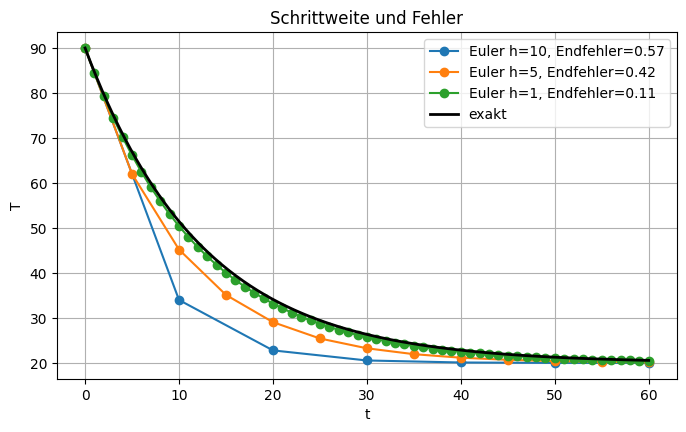

In [4]:
def euler(f, t0, y0, h, steps):
    ts = [t0]; ys = [float(y0)]
    for _ in range(steps):
        ys.append(ys[-1] + h * f(ts[-1], ys[-1]))
        ts.append(ts[-1] + h)
    return np.array(ts), np.array(ys)

for h in (10.0, 5.0, 1.0):
    te, ye = euler(lambda _, temp: -k*(temp-T_U), 0, T_0, h, int(60/h))
    error = abs(ye[-1] - (T_U + (T_0-T_U)*np.exp(-k*60)))
    plt.plot(te, ye, 'o-', label=f'Euler h={h:g}, Endfehler={error:.2f}')
plt.plot(t, T, color='black', linewidth=2, label='exakt')
plt.xlabel('t'); plt.ylabel('T'); plt.legend(); plt.title('Schrittweite und Fehler'); plt.show()

## 4. Variablentrennung

Für $y'=xy$, $y(0)=1$ folgt $y=e^{x^2/2}$. Wir prüfen die DGL symbolisch.

In [5]:
x = sp.symbols('x', real=True)
y = sp.exp(x**2 / 2)
residuum = sp.simplify(sp.diff(y, x) - x*y)
print('Residuum y\' - x y =', residuum)
print('Anfangswert y(0) =', y.subs(x, 0))
assert residuum == 0 and y.subs(x, 0) == 1

Residuum y' - x y = 0
Anfangswert y(0) = 1


## 5. DGL vom Typ $y'=f(y/x)$

Bei $y'=1+y/x$ setzen wir $y=vx$. Dann ist $y'=v+xv'$ und damit $xv'=1$. Es folgt $y=x(\ln x+C)$ für $x>0$.

In [6]:
C = sp.symbols('C')
y_hom = x * (sp.log(x) + C)
check = sp.simplify(sp.diff(y_hom, x) - (1 + y_hom/x))
display(y_hom)
print('Residuum =', check)
assert check == 0

Residuum = 0


## Übungen

1. Löse $y'=2xy$ mit $y(0)=3$.  
2. Verändere beim Kaffee-Modell $k$ und interpretiere die Halbwertszeit.  
3. Untersuche numerisch $y'=y(1-y)$ für verschiedene Anfangswerte.